# STEP 1.1 – GOOGLE DRIVE MOUNT

This step is used to mount Google Drive in Google Colab. Mounting Google Drive allows direct access to the dataset, trained models, generated results, and project files. It also ensures that the work is automatically saved and can be accessed even if the Colab session disconnects.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


STEP 1.2 – CREATE PROJECT FOLDER STRUCTURE

This step creates a well-organized project directory in Google Drive. Keeping datasets, models, results, notebooks, and reports in separate folders improves project management and makes it easier to upload the project to GitHub and prepare the final report.

In [ ]:
import os

project_path = "/content/drive/MyDrive/Malaria_Project"

folders = [
    "results",
    "models",
    "report",
    "notebooks"
]

for folder in folders:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


STEP 1.3 – VERIFY DATASET LOCATION

In [2]:
dataset_path = "/content/drive/MyDrive/Malaria_Project/datasets/cell_images"

print("Dataset Path:", dataset_path)

Dataset Path: /content/drive/MyDrive/Malaria_Project/datasets/cell_images


STEP 1.4 – VERIFY DATASET FOLDER STRUCTURE

In [3]:
import os

classes = os.listdir(dataset_path)

print("Classes Found:")
print(classes)

Classes Found:
['Uninfected', 'Parasitized']


STEP 1.3 – IMPORT REQUIRED LIBRARIES

Deep learning projects require multiple Python libraries for data manipulation, visualization, model development, evaluation, and file management. Importing all libraries at the beginning ensures that the environment is ready for the remaining project stages.

In [4]:
# =====================================================
# STEP 1.3 – IMPORT REQUIRED LIBRARIES
# =====================================================

import os
import random
import shutil
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

warnings.filterwarnings("ignore")

print("="*60)
print(" Libraries imported successfully.")
print("="*60)

 Libraries imported successfully.


In [5]:
# =====================================================
# STEP 1.5 – VERIFY DATASET LOCATION
# =====================================================

import os

DATASET_PATH = "/content/drive/MyDrive/Malaria_Project/datasets/cell_images"

print("=" * 60)
print("DATASET VERIFICATION")
print("=" * 60)

print("Dataset Path :", DATASET_PATH)
print("Folder Exists:", os.path.exists(DATASET_PATH))

DATASET VERIFICATION
Dataset Path : /content/drive/MyDrive/Malaria_Project/datasets/cell_images
Folder Exists: True


In [6]:
# =====================================================
# STEP 1.4 – CHECK GPU
# =====================================================

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*60)
print(" Device Information")
print("="*60)

print("Using Device :", device)

if torch.cuda.is_available():
    print("GPU Name :", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

 Device Information
Using Device : cpu
Running on CPU


In [7]:
# =====================================================
# STEP 1.6 – VERIFY DATASET STRUCTURE
# =====================================================

import os

classes = sorted(os.listdir(DATASET_PATH))

print("=" * 60)
print("CLASS FOLDERS FOUND")
print("=" * 60)

for i, cls in enumerate(classes, start=1):
    print(f"{i}. {cls}")

print("\nTotal Classes:", len(classes))

CLASS FOLDERS FOUND
1. Parasitized
2. Uninfected

Total Classes: 2


# PHASE 2 – EXPLORATORY DATA ANALYSIS (EDA)

STEP 2.1 – IMPORT LIBRARIES FOR EDA

In [8]:
# =====================================================
# STEP 2.1 – IMPORT LIBRARIES FOR EDA
# =====================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

print("=" * 60)
print("EDA Libraries Imported Successfully")
print("=" * 60)

EDA Libraries Imported Successfully


STEP 2.2 – DATASET INFORMATION

In [9]:
# =====================================================
# STEP 2.2 – DATASET INFORMATION
# =====================================================

dataset_path = "/content/drive/MyDrive/Malaria_Project/datasets/cell_images"

classes = sorted(os.listdir(dataset_path))

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

total_images = 0

class_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    count = len([
        img for img in os.listdir(class_path)
        if img.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

    class_counts[cls] = count
    total_images += count

    print(f"{cls:<15}: {count}")

print("-" * 60)
print(f"Total Classes : {len(classes)}")
print(f"Total Images  : {total_images}")

DATASET INFORMATION
Parasitized    : 13779
Uninfected     : 13778
------------------------------------------------------------
Total Classes : 2
Total Images  : 27557


In [10]:
# =====================================================
# CREATE BALANCED DATASET SUBSET
# =====================================================

import os
import random
import shutil

random.seed(42)

original_dataset = "/content/drive/MyDrive/Malaria_Project/datasets/cell_images"
subset_dataset = "/content/drive/MyDrive/Malaria_Project/datasets/malaria_subset"

classes = ["Parasitized", "Uninfected"]

IMAGES_PER_CLASS = 6500

for cls in classes:

    source = os.path.join(original_dataset, cls)
    destination = os.path.join(subset_dataset, cls)

    os.makedirs(destination, exist_ok=True)

    images = [
        img for img in os.listdir(source)
        if img.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    selected = random.sample(images, IMAGES_PER_CLASS)

    print(f"\nCopying {cls} images...")

    for img in selected:
        shutil.copy2(
            os.path.join(source, img),
            os.path.join(destination, img)
        )

    print(f"{cls}: {len(selected)} images copied.")

print("\n")
print("="*60)
print("Balanced subset created successfully.")
print("="*60)


Copying Parasitized images...
Parasitized: 6500 images copied.

Copying Uninfected images...
Uninfected: 6500 images copied.


Balanced subset created successfully.


In [10]:
# =====================================================
# VERIFY SUBSET
# =====================================================

subset_path = "/content/drive/MyDrive/Malaria_Project/datasets/malaria_subset"

for cls in sorted(os.listdir(subset_path)):

    class_path = os.path.join(subset_path, cls)

    count = len(os.listdir(class_path))

    print(f"{cls:<15}: {count}")

print("\nTotal Images:", sum(
    len(os.listdir(os.path.join(subset_path, c)))
    for c in os.listdir(subset_path)
))

Parasitized    : 6500
Uninfected     : 6500

Total Images: 13000


In [11]:
dataset_path = "/content/drive/MyDrive/Malaria_Project/datasets/malaria_subset"

STEP 2.3 – VISUALIZE CLASS DISTRIBUTION

In [ ]:
# =====================================================
# CREATE FIGURES FOLDER
# =====================================================

import os

FIGURE_PATH = "/content/drive/MyDrive/Malaria_Project/figures"

os.makedirs(FIGURE_PATH, exist_ok=True)

print("✅ Figures folder is ready.")

✅ Figures folder is ready.


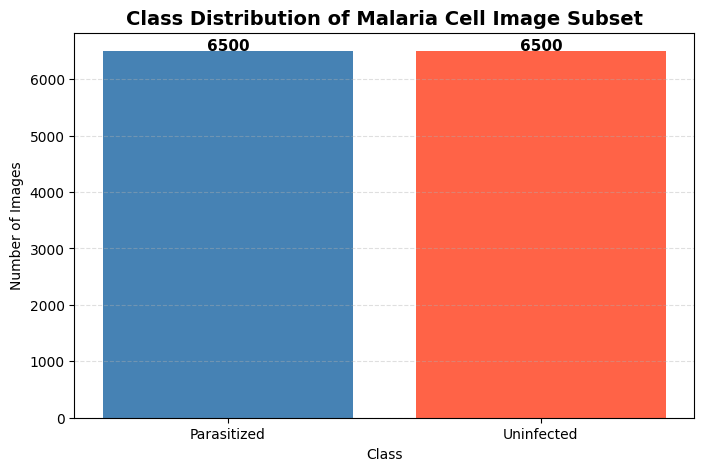


Figure Saved Successfully!


In [14]:
# =====================================================
# STEP 2.3 – CLASS DISTRIBUTION
# =====================================================

import matplotlib.pyplot as plt
import os

# Create figures folder if it doesn't exist
os.makedirs("/content/drive/MyDrive/Malaria_Project/figures", exist_ok=True)

class_names = list(class_counts.keys())
image_counts = list(class_counts.values())

plt.figure(figsize=(8,5))

bars = plt.bar(
    class_names,
    image_counts,
    color=["steelblue","tomato"]
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+20,
        f"{height}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title("Class Distribution of Malaria Cell Image Subset",fontsize=14,fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.grid(axis="y",linestyle="--",alpha=0.4)

save_path="/content/drive/MyDrive/Malaria_Project/figures/class_distribution.png"

plt.savefig(save_path,dpi=300,bbox_inches="tight")

plt.show()

print("\nFigure Saved Successfully!")

STEP 2.4 – DISPLAY RANDOM SAMPLE IMAGES

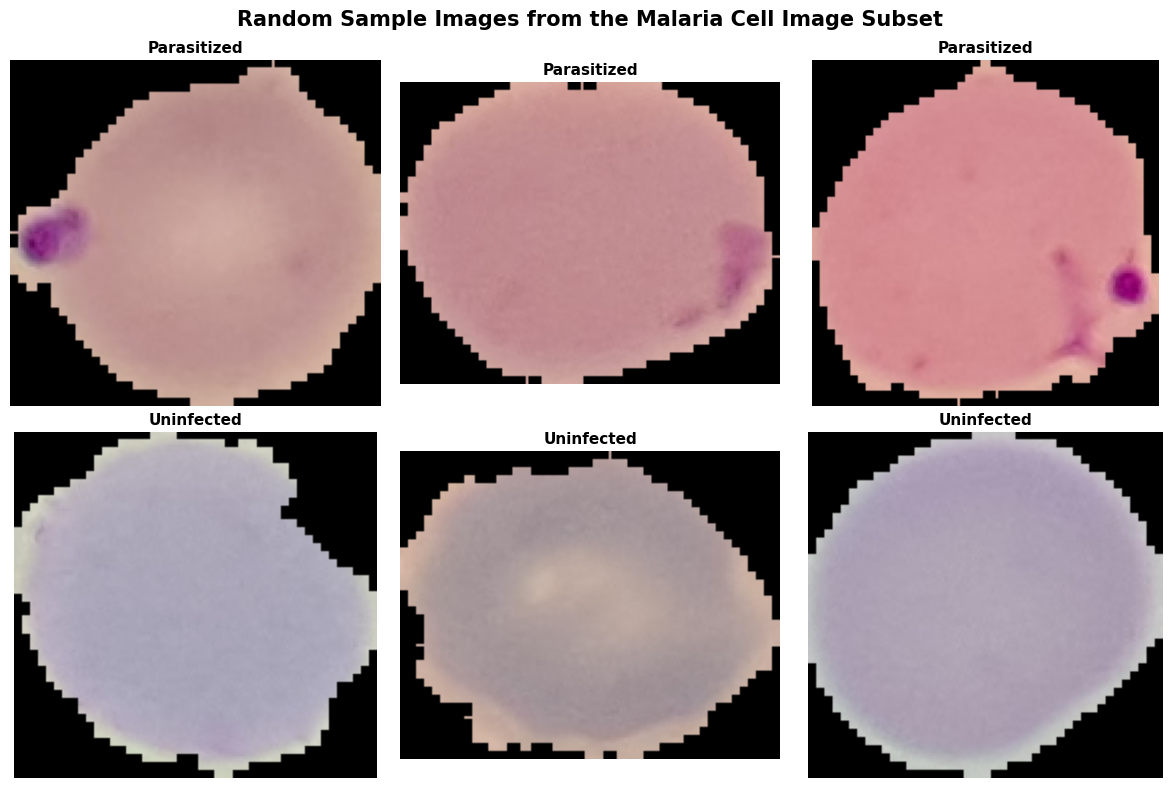

Figure saved successfully!
/content/drive/MyDrive/Malaria_Project/figures/sample_images.png


In [15]:
# =====================================================
# STEP 2.4 – DISPLAY RANDOM SAMPLE IMAGES
# =====================================================

import os
import random
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = "/content/drive/MyDrive/Malaria_Project/datasets/malaria_subset"

classes = ["Parasitized", "Uninfected"]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for row, cls in enumerate(classes):

    class_path = os.path.join(dataset_path, cls)

    image_list = [
        img for img in os.listdir(class_path)
        if img.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    selected_images = random.sample(image_list, 3)

    for col, image_name in enumerate(selected_images):

        img_path = os.path.join(class_path, image_name)

        img = Image.open(img_path)

        axes[row, col].imshow(img)
        axes[row, col].set_title(cls, fontsize=11, fontweight="bold")
        axes[row, col].axis("off")

plt.suptitle(
    "Random Sample Images from the Malaria Cell Image Subset",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

save_path = "/content/drive/MyDrive/Malaria_Project/figures/sample_images.png"

plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved successfully!")
print(save_path)

STEP 2.5 – IMAGE RESOLUTION ANALYSIS

Image resolution analysis is an important part of Exploratory Data Analysis (EDA). This step examines the width and height of all images in the dataset to understand their original dimensions. Since deep learning models require images of a fixed size, this analysis justifies resizing all images to 224 × 224 pixels during preprocessing. It also helps identify any irregular image dimensions.

In [16]:
# =====================================================
# STEP 2.5 – IMAGE RESOLUTION ANALYSIS
# =====================================================

import os
import numpy as np
from PIL import Image

dataset_path = "/content/drive/MyDrive/Malaria_Project/datasets/malaria_subset"

widths = []
heights = []

for cls in ["Parasitized", "Uninfected"]:

    class_path = os.path.join(dataset_path, cls)

    for image_name in os.listdir(class_path):

        if image_name.lower().endswith((".png", ".jpg", ".jpeg")):

            img_path = os.path.join(class_path, image_name)

            try:
                img = Image.open(img_path)
                w, h = img.size

                widths.append(w)
                heights.append(h)

            except:
                pass

print("=" * 60)
print("IMAGE RESOLUTION ANALYSIS")
print("=" * 60)

print(f"Total Images        : {len(widths)}")
print(f"Minimum Width       : {min(widths)}")
print(f"Maximum Width       : {max(widths)}")
print(f"Average Width       : {np.mean(widths):.2f}")

print()

print(f"Minimum Height      : {min(heights)}")
print(f"Maximum Height      : {max(heights)}")
print(f"Average Height      : {np.mean(heights):.2f}")

IMAGE RESOLUTION ANALYSIS
Total Images        : 13000
Minimum Width       : 46
Maximum Width       : 364
Average Width       : 132.33

Minimum Height      : 40
Maximum Height      : 385
Average Height      : 132.94


STEP 2.6 – IMAGE SIZE DISTRIBUTION

This step visualizes the distribution of image widths and heights in the dataset. It helps identify the variation in image dimensions and provides evidence for the resizing strategy adopted during preprocessing.

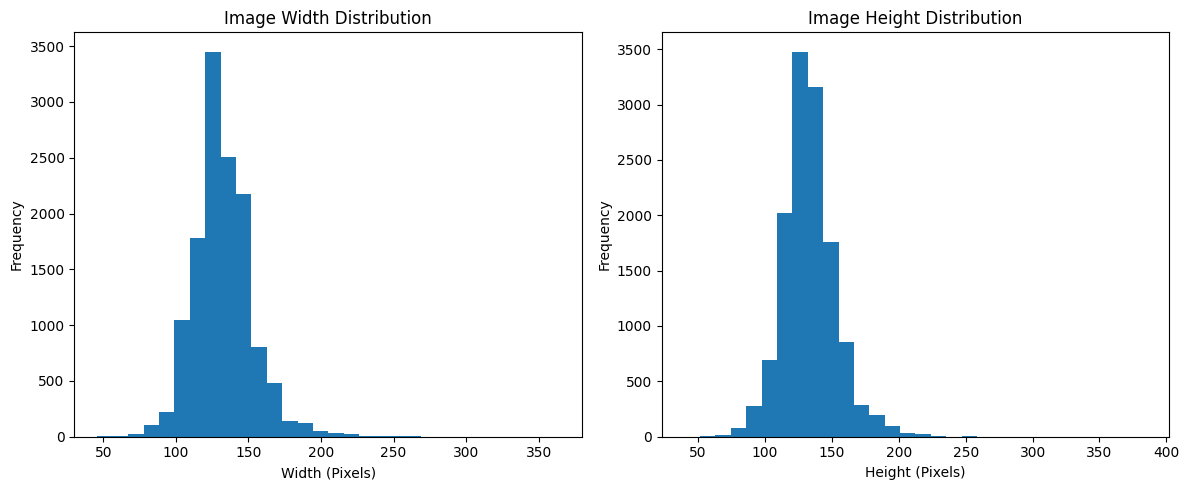

Figure saved successfully!
/content/drive/MyDrive/Malaria_Project/figures/image_resolution_distribution.png


In [17]:
# =====================================================
# STEP 2.6 – IMAGE SIZE DISTRIBUTION
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(widths, bins=30)
plt.title("Image Width Distribution")
plt.xlabel("Width (Pixels)")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(heights, bins=30)
plt.title("Image Height Distribution")
plt.xlabel("Height (Pixels)")
plt.ylabel("Frequency")

plt.tight_layout()

save_path = "/content/drive/MyDrive/Malaria_Project/figures/image_resolution_distribution.png"

plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved successfully!")
print(save_path)

# PHASE 3 – DATA PREPROCESSING

STEP 3.1 – CREATE TRAIN, VALIDATION, AND TEST SPLIT (80/10/10)

Before training the deep learning models, the dataset must be divided into three subsets:

Training Set (80%) – Used to train the CNN and MobileNetV2 models.
Validation Set (10%) – Used during training to monitor model performance and tune hyperparameters.
Test Set (10%) – Used only after training to evaluate the final model on unseen data.

Using separate datasets helps prevent overfitting and provides an unbiased estimate of model performance.

In [18]:
# =====================================================
# STEP 3.1 – CREATE TRAIN / VALIDATION / TEST SPLIT
# =====================================================

import os
import shutil
import random

random.seed(42)

# Original subset path
dataset_path = "/content/drive/MyDrive/Malaria_Project/datasets/malaria_subset"

# Destination path
split_path = "/content/drive/MyDrive/Malaria_Project/datasets/split_dataset"

classes = ["Parasitized", "Uninfected"]

# Split ratios
train_ratio = 0.80
val_ratio = 0.10
test_ratio = 0.10

# Create folders
for split in ["train", "validation", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(split_path, split, cls), exist_ok=True)

# Copy images
for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    random.shuffle(images)

    total = len(images)

    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    for img in train_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(split_path, "train", cls, img)
        )

    for img in val_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(split_path, "validation", cls, img)
        )

    for img in test_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(split_path, "test", cls, img)
        )

print("=" * 60)
print("Dataset split completed successfully!")
print("=" * 60)

Dataset split completed successfully!


STEP 3.2 – VERIFY DATASET SPLIT

After splitting the dataset, it is important to verify the number of images in each subset. This ensures that the 80/10/10 split has been performed correctly and that both classes remain balanced across the training, validation, and testing sets.

In [12]:
# =====================================================
# STEP 3.2 – VERIFY DATASET SPLIT
# =====================================================

split_path = "/content/drive/MyDrive/Malaria_Project/datasets/split_dataset"

for split in ["train", "validation", "test"]:

    print("=" * 60)
    print(split.upper())
    print("=" * 60)

    total = 0

    for cls in classes:

        count = len(os.listdir(os.path.join(split_path, split, cls)))

        total += count

        print(f"{cls:<15}: {count}")

    print("-" * 60)
    print(f"Total Images : {total}")
    print()

TRAIN
Parasitized    : 5200
Uninfected     : 5200
------------------------------------------------------------
Total Images : 10400

VALIDATION
Parasitized    : 650
Uninfected     : 650
------------------------------------------------------------
Total Images : 1300

TEST
Parasitized    : 650
Uninfected     : 650
------------------------------------------------------------
Total Images : 1300



STEP 3.3 – DEFINE IMAGE TRANSFORMATIONS

Deep learning models require all input images to have the same size and pixel distribution. This step defines the preprocessing transformations that will be applied to the training, validation, and testing datasets. Data augmentation is applied only to the training dataset to increase image diversity, reduce overfitting, and improve model generalization. Validation and testing datasets undergo only resizing and normalization to ensure fair model evaluation.

In [13]:
# =====================================================
# STEP 3.3 – DEFINE IMAGE TRANSFORMATIONS
# =====================================================

from torchvision import transforms

# Training Transformations
train_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation Transformations
validation_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Test Transformations
test_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("=" * 60)
print("Image transformations created successfully.")
print("=" * 60)

Image transformations created successfully.


STEP 3.4 – CREATE PYTORCH DATASETS

This step loads the training, validation, and testing images using PyTorch's ImageFolder class. Each dataset is associated with its respective preprocessing transformations defined in the previous step. Using ImageFolder simplifies image loading and automatically assigns labels based on the folder names.

In [14]:
# =====================================================
# STEP 3.4 – CREATE PYTORCH DATASETS
# =====================================================

from torchvision.datasets import ImageFolder

split_path = "/content/drive/MyDrive/Malaria_Project/datasets/split_dataset"

train_dataset = ImageFolder(
    root=os.path.join(split_path, "train"),
    transform=train_transform
)

validation_dataset = ImageFolder(
    root=os.path.join(split_path, "validation"),
    transform=validation_transform
)

test_dataset = ImageFolder(
    root=os.path.join(split_path, "test"),
    transform=test_transform
)

print("=" * 60)
print("Datasets Loaded Successfully")
print("=" * 60)

print(f"Training Images   : {len(train_dataset)}")
print(f"Validation Images : {len(validation_dataset)}")
print(f"Testing Images    : {len(test_dataset)}")

print("\nClasses:", train_dataset.classes)

Datasets Loaded Successfully
Training Images   : 10400
Validation Images : 1300
Testing Images    : 1300

Classes: ['Parasitized', 'Uninfected']


STEP 3.5 – CREATE PYTORCH DATALOADERS

Deep learning models process images in batches rather than one image at a time. A PyTorch DataLoader efficiently loads images from the dataset, applies preprocessing transformations, shuffles the training data, and prepares mini-batches for model training. Using DataLoaders improves memory management and speeds up the training process.

In [15]:
# =====================================================
# STEP 3.5 – CREATE PYTORCH DATALOADERS
# =====================================================

from torch.utils.data import DataLoader

# Hyperparameters
BATCH_SIZE = 32
NUM_WORKERS = 2

# Training DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

# Validation DataLoader
validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

# Testing DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("=" * 60)
print("DataLoaders Created Successfully")
print("=" * 60)

print(f"Training Batches   : {len(train_loader)}")
print(f"Validation Batches : {len(validation_loader)}")
print(f"Testing Batches    : {len(test_loader)}")

DataLoaders Created Successfully
Training Batches   : 325
Validation Batches : 41
Testing Batches    : 41


STEP 3.6 – VERIFY DATALOADER OUTPUT

Before training the deep learning models, it is important to verify that the DataLoaders are working correctly. This step checks the shape of one batch of images and labels to ensure the data has been resized, normalized, and grouped into the expected batch size.

In [16]:
# =====================================================
# STEP 3.6 – VERIFY DATALOADER OUTPUT
# =====================================================

images, labels = next(iter(train_loader))

print("=" * 60)
print("DATALOADER VERIFICATION")
print("=" * 60)

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

print("\nFirst 10 Labels:")
print(labels[:10])

DATALOADER VERIFICATION
Image Batch Shape : torch.Size([32, 3, 224, 224])
Label Batch Shape : torch.Size([32])

First 10 Labels:
tensor([0, 0, 0, 1, 1, 0, 0, 0, 1, 1])


STEP 3.7 – VISUALIZE AUGMENTED TRAINING IMAGES

This step displays a batch of transformed training images after data augmentation. It helps verify that resizing, random flipping, rotation, and normalization have been applied correctly before model training.

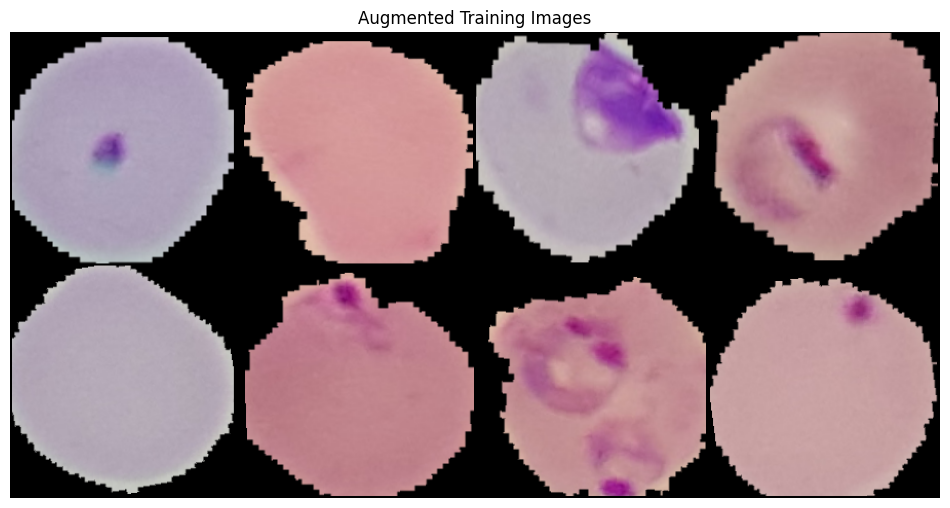

In [17]:
# =====================================================
# STEP 3.7 – VISUALIZE AUGMENTED TRAINING IMAGES
# =====================================================

import matplotlib.pyplot as plt
import torchvision

# Get one batch
images, labels = next(iter(train_loader))

# Undo normalization for visualization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

images = images * std + mean
images = torch.clamp(images, 0, 1)

plt.figure(figsize=(12,8))

grid = torchvision.utils.make_grid(images[:8], nrow=4)

plt.imshow(grid.permute(1,2,0))
plt.axis("off")
plt.title("Augmented Training Images")

plt.show()

# STEP 4.1 – BUILD CNN ARCHITECTURE

This step defines a custom Convolutional Neural Network (CNN) for malaria cell image classification. The network learns hierarchical image features through convolutional layers, reduces spatial dimensions using max pooling, and performs binary classification using fully connected layers. The architecture is designed to balance classification performance and computational efficiency.

In [31]:
# =====================================================
# STEP 4.1 – FINAL CNN ARCHITECTURE
# =====================================================

import torch
import torch.nn as nn

class MalariaCNN(nn.Module):

    def __init__(self):
        super(MalariaCNN, self).__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Reduce feature map
            nn.AdaptiveAvgPool2d((1,1))
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128, 128),

            nn.ReLU(inplace=True),

            nn.Dropout(0.5),

            nn.Linear(128, 2)

        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


model = MalariaCNN().to(device)

print("="*70)
print("FINAL CNN MODEL CREATED SUCCESSFULLY")
print("="*70)

FINAL CNN MODEL CREATED SUCCESSFULLY



STEP 4.2 – DISPLAY CNN MODEL ARCHITECTURE

This step prints the complete CNN architecture. It allows us to verify that all convolutional, activation, pooling, and fully connected layers have been defined correctly before training begins. Displaying the model architecture also helps explain the network design in the project report and viva presentation.

In [32]:
# =====================================================
# STEP 4.2 – DISPLAY CNN MODEL ARCHITECTURE
# =====================================================

print("=" * 70)
print("CNN MODEL ARCHITECTURE")
print("=" * 70)

print(model)

CNN MODEL ARCHITECTURE
MalariaCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1

STEP 4.3 – COUNT TRAINABLE PARAMETERS

The number of trainable parameters indicates the complexity of the neural network. Models with more parameters generally have greater learning capacity but also require more memory and computational resources. Reporting the number of parameters is part of computational performance analysis.

In [33]:
# =====================================================
# STEP 4.3 – COUNT TRAINABLE PARAMETERS
# =====================================================

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print("=" * 70)
print("MODEL PARAMETERS")
print("=" * 70)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

MODEL PARAMETERS
Total Parameters     : 110,466
Trainable Parameters : 110,466


STEP 4.4 – DEFINE LOSS FUNCTION

The loss function measures the difference between the model's predicted outputs and the true class labels. During training, the objective is to minimize this loss so that the model learns to make more accurate predictions. For this binary image classification task, CrossEntropyLoss is used because it is the standard loss function for multi-class classification problems in PyTorch (including binary classification with two output neurons).

In [34]:
# =====================================================
# STEP 4.4 – DEFINE LOSS FUNCTION
# =====================================================

import torch.nn as nn

criterion = nn.CrossEntropyLoss()

print("=" * 70)
print("LOSS FUNCTION")
print("=" * 70)
print("Loss Function :", criterion)

LOSS FUNCTION
Loss Function : CrossEntropyLoss()


STEP 4.5 – DEFINE OPTIMIZER

The optimizer updates the model's trainable parameters using the gradients computed during backpropagation. In this project, the Adam optimizer is selected because it combines the advantages of adaptive learning rates and momentum, resulting in faster and more stable convergence than traditional gradient descent methods.

In [35]:
# =====================================================
# STEP 4.5 – DEFINE OPTIMIZER
# =====================================================

import torch.optim as optim

LEARNING_RATE = 0.001

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("=" * 70)
print("OPTIMIZER")
print("=" * 70)
print("Optimizer :", optimizer)

OPTIMIZER
Optimizer : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


STEP 4.6 – DEFINE TRAINING HYPERPARAMETERS

Hyperparameters control the training process and directly influence model performance. These settings determine how many times the dataset is processed, the number of images used in each training batch, and when training should stop to prevent overfitting.

In [36]:
# =====================================================
# STEP 4.6 – DEFINE TRAINING HYPERPARAMETERS
# =====================================================

EPOCHS = 15
BATCH_SIZE = 32
LEARNING_RATE = 0.001
PATIENCE = 5

print("=" * 70)
print("TRAINING HYPERPARAMETERS")
print("=" * 70)

print(f"Epochs              : {EPOCHS}")
print(f"Batch Size          : {BATCH_SIZE}")
print(f"Learning Rate       : {LEARNING_RATE}")
print(f"Early Stop Patience : {PATIENCE}")

TRAINING HYPERPARAMETERS
Epochs              : 15
Batch Size          : 32
Learning Rate       : 0.001
Early Stop Patience : 5


STEP 4.7 – TRAIN THE CNN MODEL

This step trains the CNN model using the training dataset and evaluates its performance on the validation dataset after each epoch. During training, forward propagation computes predictions, the loss function measures prediction errors, backpropagation calculates gradients, and the Adam optimizer updates the model weights. Early stopping is used to prevent overfitting by terminating training if the validation loss does not improve for several consecutive epochs. The best-performing model is automatically saved for later evaluation.

In [37]:
# =====================================================
# STEP 4.7 – TRAIN CNN MODEL
# =====================================================

import torch
import copy
import time

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Save best model
BEST_MODEL_PATH = "/content/drive/MyDrive/Malaria_Project/models/best_cnn_model.pth"

best_val_loss = float("inf")
best_model_weights = copy.deepcopy(model.state_dict())

early_stop_counter = 0

# History
train_loss_history = []
val_loss_history = []

train_accuracy_history = []
val_accuracy_history = []

start_time = time.time()

for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    ########################################
    # TRAINING
    ########################################

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)

    train_accuracy = 100 * correct / total

    ########################################
    # VALIDATION
    ########################################

    model.eval()

    running_val_loss = 0

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in validation_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted==labels).sum().item()

    val_loss = running_val_loss / len(validation_loader)

    val_accuracy = 100 * correct / total

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    train_accuracy_history.append(train_accuracy)
    val_accuracy_history.append(val_accuracy)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Accuracy : {train_accuracy:.2f}%")

    print(f"Validation Loss : {val_loss:.4f}")
    print(f"Validation Accuracy : {val_accuracy:.2f}%")

    ########################################
    # SAVE BEST MODEL
    ########################################

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_weights = copy.deepcopy(model.state_dict())

        torch.save(best_model_weights, BEST_MODEL_PATH)

        early_stop_counter = 0

        print("✅ Best model saved.")

    else:

        early_stop_counter += 1

        print(f"No Improvement ({early_stop_counter}/{PATIENCE})")

    ########################################
    # EARLY STOPPING
    ########################################

    if early_stop_counter >= PATIENCE:

        print("\nEarly stopping activated!")

        break


training_time = time.time() - start_time

print("\n" + "="*70)
print("CNN TRAINING COMPLETED")
print("="*70)

print(f"Training Time : {training_time/60:.2f} minutes")


Epoch [1/15]
Train Loss : 0.4849
Train Accuracy : 79.02%
Validation Loss : 1.3374
Validation Accuracy : 50.00%
✅ Best model saved.

Epoch [2/15]
Train Loss : 0.2632
Train Accuracy : 90.98%
Validation Loss : 0.1983
Validation Accuracy : 93.54%
✅ Best model saved.

Epoch [3/15]
Train Loss : 0.2282
Train Accuracy : 92.26%
Validation Loss : 0.1623
Validation Accuracy : 95.85%
✅ Best model saved.

Epoch [4/15]
Train Loss : 0.2066
Train Accuracy : 93.44%
Validation Loss : 0.1631
Validation Accuracy : 95.38%
No Improvement (1/5)

Epoch [5/15]
Train Loss : 0.2129
Train Accuracy : 93.07%
Validation Loss : 0.1552
Validation Accuracy : 95.23%
✅ Best model saved.

Epoch [6/15]
Train Loss : 0.1963
Train Accuracy : 93.99%
Validation Loss : 0.1631
Validation Accuracy : 95.92%
No Improvement (1/5)

Epoch [7/15]
Train Loss : 0.1973
Train Accuracy : 94.08%
Validation Loss : 0.1583
Validation Accuracy : 95.85%
No Improvement (2/5)

Epoch [8/15]
Train Loss : 0.1897
Train Accuracy : 94.22%
Validation Loss

STEP 4.8 – PLOT TRAINING AND VALIDATION LOSS

The training and validation loss curves illustrate how the CNN model learns over time. A decreasing loss indicates that the model is improving its predictions. Comparing training and validation loss also helps detect overfitting or underfitting during training.

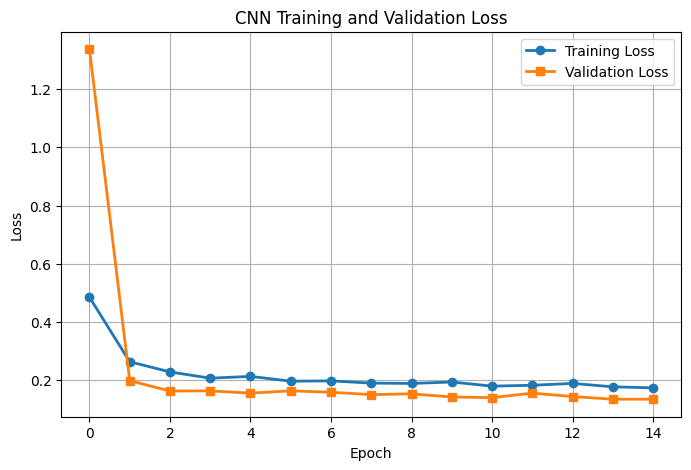

Loss curve saved successfully!
/content/drive/MyDrive/Malaria_Project/figures/cnn_loss_curve.png


In [38]:
# =====================================================
# STEP 4.8 – PLOT TRAINING & VALIDATION LOSS
# =====================================================

import matplotlib.pyplot as plt
import os

# Create figures folder if it doesn't exist
os.makedirs("/content/drive/MyDrive/Malaria_Project/figures", exist_ok=True)

plt.figure(figsize=(8,5))

plt.plot(train_loss_history,
         marker='o',
         linewidth=2,
         label='Training Loss')

plt.plot(val_loss_history,
         marker='s',
         linewidth=2,
         label='Validation Loss')

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

save_path="/content/drive/MyDrive/Malaria_Project/figures/cnn_loss_curve.png"

plt.savefig(save_path,dpi=300,bbox_inches="tight")

plt.show()

print("Loss curve saved successfully!")
print(save_path)


STEP 4.9 – PLOT TRAINING AND VALIDATION ACCURACY

Accuracy curves show how the model's prediction performance changes during training. Comparing training and validation accuracy helps determine whether the model generalizes well or begins to overfit the training data.

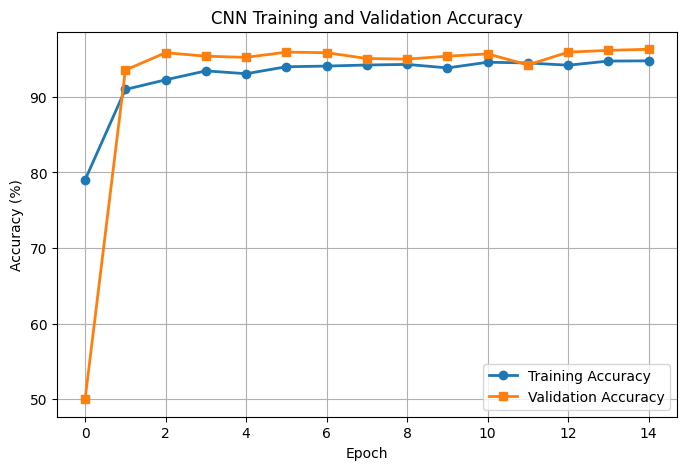

Accuracy curve saved successfully!
/content/drive/MyDrive/Malaria_Project/figures/cnn_accuracy_curve.png


In [39]:
# =====================================================
# STEP 4.9 – PLOT TRAINING & VALIDATION ACCURACY
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(train_accuracy_history,
         marker='o',
         linewidth=2,
         label='Training Accuracy')

plt.plot(val_accuracy_history,
         marker='s',
         linewidth=2,
         label='Validation Accuracy')

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

save_path="/content/drive/MyDrive/Malaria_Project/figures/cnn_accuracy_curve.png"

plt.savefig(save_path,dpi=300,bbox_inches="tight")

plt.show()

print("Accuracy curve saved successfully!")
print(save_path)

STEP 4.10 – LOAD THE BEST SAVED CNN MODEL

During training, the model with the lowest validation loss was automatically saved. This step loads that best-performing model to ensure the final evaluation is carried out using the most effective version of the CNN.

In [40]:
# =====================================================
# STEP 4.10 – LOAD BEST CNN MODEL
# =====================================================

import torch

BEST_MODEL_PATH = "/content/drive/MyDrive/Malaria_Project/models/best_cnn_model.pth"

# Load best weights
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))

model.eval()

print("="*70)
print("BEST CNN MODEL LOADED SUCCESSFULLY")
print("="*70)

BEST CNN MODEL LOADED SUCCESSFULLY


STEP 4.11 – EVALUATE THE CNN MODEL ON THE TEST SET

The test dataset contains images that were never used during training or validation. Evaluating on this unseen data provides an unbiased estimate of the model's real-world performance.

In [41]:
# =====================================================
# STEP 4.11 – TEST SET EVALUATION
# =====================================================

from sklearn.metrics import accuracy_score

all_labels = []
all_predictions = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

test_accuracy = accuracy_score(all_labels, all_predictions)

print("="*70)
print("CNN TEST PERFORMANCE")
print("="*70)

print(f"Test Accuracy : {test_accuracy*100:.2f}%")

CNN TEST PERFORMANCE
Test Accuracy : 95.15%


STEP 4.12 – CLASSIFICATION REPORT

Accuracy alone does not fully describe model performance. The classification report provides Precision, Recall, and F1-score for each class, offering a more comprehensive evaluation.

In [42]:
# =====================================================
# STEP 4.12 – CLASSIFICATION REPORT
# =====================================================

from sklearn.metrics import classification_report

print("="*70)
print("CLASSIFICATION REPORT")
print("="*70)

print(classification_report(
    all_labels,
    all_predictions,
    target_names=train_dataset.classes
))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Parasitized       0.96      0.95      0.95       650
  Uninfected       0.95      0.96      0.95       650

    accuracy                           0.95      1300
   macro avg       0.95      0.95      0.95      1300
weighted avg       0.95      0.95      0.95      1300



STEP 4.13 – CONFUSION MATRIX

A confusion matrix summarizes the model's predictions by comparing predicted labels with the actual labels. It highlights correct classifications and misclassifications, helping identify where the model makes errors.

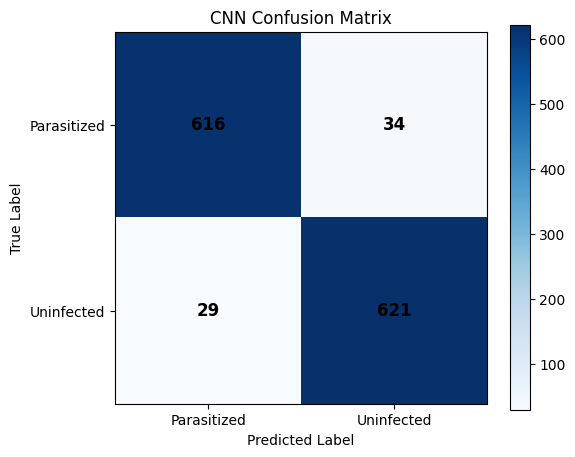

Confusion matrix saved successfully!


In [43]:
# =====================================================
# STEP 4.13 – CONFUSION MATRIX
# =====================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(6,5))

plt.imshow(cm, interpolation='nearest', cmap='Blues')

plt.title("CNN Confusion Matrix")

plt.colorbar()

classes = train_dataset.classes

tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)

plt.yticks(tick_marks, classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color="black",
            fontsize=12,
            fontweight="bold"
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

save_path = "/content/drive/MyDrive/Malaria_Project/figures/cnn_confusion_matrix.png"

plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Confusion matrix saved successfully!")

# PHASE 5 – TRANSFER LEARNING USING MOBILENETV2

Transfer learning uses a model that has already been trained on a very large dataset (ImageNet with over 1 million images). Instead of learning from scratch, the model reuses previously learned visual features such as edges, textures, and shapes. This generally results in faster convergence, better generalization, and higher classification accuracy, especially for medical image datasets.

STEP 5.1 – IMPORT REQUIRED LIBRARIES

In [18]:
# =====================================================
# STEP 5.1 – IMPORT LIBRARIES
# =====================================================

import torch
import torch.nn as nn

from torchvision import models

print("="*70)
print("LIBRARIES IMPORTED SUCCESSFULLY")
print("="*70)

LIBRARIES IMPORTED SUCCESSFULLY


STEP 5.2 – LOAD PRETRAINED MOBILENETV2

This step loads the pretrained MobileNetV2 model. The pretrained weights have already learned general visual features from the ImageNet dataset. These learned features are transferred to the malaria classification task, reducing training time and improving performance.

In [19]:
# =====================================================
# STEP 5.2 – LOAD PRETRAINED MOBILENETV2
# =====================================================

mobile_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

print("="*70)
print("PRETRAINED MOBILENETV2 LOADED SUCCESSFULLY")
print("="*70)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 80.6MB/s]


PRETRAINED MOBILENETV2 LOADED SUCCESSFULLY


STEP 5.3 – FREEZE FEATURE EXTRACTION LAYERS

The convolutional layers of MobileNetV2 already contain useful feature representations learned from ImageNet. Freezing these layers prevents their weights from being updated during training, reducing computational cost and minimizing the risk of overfitting. Only the newly added classifier will be trained for the malaria classification task.

In [20]:
# =====================================================
# STEP 5.3 – FREEZE FEATURE EXTRACTION
# =====================================================

for param in mobile_model.features.parameters():
    param.requires_grad = False

print("="*70)
print("FEATURE EXTRACTION LAYERS FROZEN")
print("="*70)

FEATURE EXTRACTION LAYERS FROZEN


STEP 5.4 – REPLACE THE CLASSIFIER

The original MobileNetV2 classifier is designed for 1000 ImageNet classes. Since this project involves binary classification (Parasitized vs Uninfected), the classifier must be replaced with a new fully connected network that outputs two classes.

In [21]:
# =====================================================
# STEP 5.4 – REPLACE CLASSIFIER
# =====================================================

mobile_model.classifier = nn.Sequential(

    nn.Dropout(0.3),

    nn.Linear(
        mobile_model.last_channel,
        128
    ),

    nn.ReLU(inplace=True),

    nn.Dropout(0.3),

    nn.Linear(128,2)

)

mobile_model = mobile_model.to(device)

print("="*70)
print("CUSTOM CLASSIFIER ADDED SUCCESSFULLY")
print("="*70)

CUSTOM CLASSIFIER ADDED SUCCESSFULLY


STEP 5.5 – DISPLAY MODEL SUMMARY

This step verifies that the classifier has been successfully replaced and confirms the overall architecture before training.

In [22]:
# =====================================================
# STEP 5.5 – DISPLAY MODEL
# =====================================================

print("="*70)
print("MOBILENETV2 ARCHITECTURE")
print("="*70)

print(mobile_model)

MOBILENETV2 ARCHITECTURE
MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          

STEP 5.6 – COUNT TRAINABLE PARAMETERS

This step reports the number of total and trainable parameters. Since the feature extraction layers are frozen, only the classifier parameters will be trainable. This demonstrates the computational efficiency of transfer learning compared to training a full model from scratch.

In [23]:
# =====================================================
# STEP 5.6 – COUNT PARAMETERS
# =====================================================

total_params = sum(p.numel() for p in mobile_model.parameters())

trainable_params = sum(
    p.numel()
    for p in mobile_model.parameters()
    if p.requires_grad
)

print("="*70)
print("MOBILENETV2 PARAMETERS")
print("="*70)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

MOBILENETV2 PARAMETERS
Total Parameters     : 2,388,098
Trainable Parameters : 164,226


STEP 5.7 – DEFINE LOSS FUNCTION & OPTIMIZER

This step defines the loss function and optimizer for training the MobileNetV2 model. Since only the custom classifier is trainable, the optimizer updates only those parameters, making training faster and more computationally efficient.

In [24]:
# =====================================================
# STEP 5.7 – LOSS FUNCTION & OPTIMIZER
# =====================================================

import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad,
           mobile_model.parameters()),
    lr=0.001
)

print("="*70)
print("LOSS FUNCTION AND OPTIMIZER READY")
print("="*70)

LOSS FUNCTION AND OPTIMIZER READY


STEP 5.8 – DEFINE HYPERPARAMETERS

This step specifies the training hyperparameters for MobileNetV2. The same batch size and learning rate are used as in the CNN experiment to ensure a fair comparison.

In [25]:
# =====================================================
# STEP 5.8 – HYPERPARAMETERS
# =====================================================

EPOCHS = 15
PATIENCE = 5

print("="*70)
print("TRAINING CONFIGURATION")
print("="*70)

print(f"Epochs : {EPOCHS}")
print(f"Learning Rate : 0.001")
print(f"Batch Size : 32")
print(f"Early Stopping : {PATIENCE}")

TRAINING CONFIGURATION
Epochs : 15
Learning Rate : 0.001
Batch Size : 32
Early Stopping : 5


STEP 5.9 – CREATE REUSABLE TRAINING FUNCTION

Instead of writing separate training code for each deep learning model, a reusable training function is created. This function performs training, validation, early stopping, and model checkpointing. Reusing the same function improves code readability, reduces duplication, and ensures both models are trained under identical experimental conditions for a fair comparison.

In [26]:
# =====================================================
# STEP 5.9 – CREATE REUSABLE TRAINING FUNCTION
# =====================================================

import copy
import time
import torch

def train_model(
    model,
    train_loader,
    validation_loader,
    criterion,
    optimizer,
    device,
    epochs,
    patience,
    model_path
):

    best_val_loss = float("inf")
    best_weights = copy.deepcopy(model.state_dict())

    early_stop_counter = 0

    train_loss_history = []
    val_loss_history = []

    train_accuracy_history = []
    val_accuracy_history = []

    start_time = time.time()

    for epoch in range(epochs):

        epoch_start = time.time()

        print(f"\nEpoch [{epoch+1}/{epochs}]")

        # -----------------------------
        # TRAINING
        # -----------------------------

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total

        # -----------------------------
        # VALIDATION
        # -----------------------------

        model.eval()

        running_val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in validation_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                running_val_loss += loss.item()

                _, predicted = torch.max(outputs,1)

                total += labels.size(0)

                correct += (predicted==labels).sum().item()

        val_loss = running_val_loss / len(validation_loader)

        val_accuracy = 100 * correct / total

        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)

        train_accuracy_history.append(train_accuracy)
        val_accuracy_history.append(val_accuracy)

        print(f"Train Loss : {train_loss:.4f}")
        print(f"Train Accuracy : {train_accuracy:.2f}%")

        print(f"Validation Loss : {val_loss:.4f}")
        print(f"Validation Accuracy : {val_accuracy:.2f}%")

        # Save Best Model

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_weights = copy.deepcopy(model.state_dict())

            torch.save(best_weights, model_path)

            early_stop_counter = 0

            print("✅ Best model saved.")

        else:

            early_stop_counter += 1

            print(f"No Improvement ({early_stop_counter}/{patience})")

        epoch_time = time.time() - epoch_start

        print(f"Epoch Time : {epoch_time:.2f} seconds")

        if early_stop_counter >= patience:

            print("\nEarly stopping activated!")

            break

    total_training_time = time.time() - start_time

    print("\n" + "="*70)
    print("TRAINING COMPLETED")
    print("="*70)

    print(f"Total Training Time : {total_training_time/60:.2f} minutes")

    return (
        train_loss_history,
        val_loss_history,
        train_accuracy_history,
        val_accuracy_history
    )

STEP 5.10 – TRAIN MOBILENETV2

This step trains the MobileNetV2 model using the reusable training function. Since the feature extraction layers are frozen, only the custom classifier is updated, resulting in faster training while leveraging pretrained ImageNet features.

In [27]:
# =====================================================
# STEP 5.10 – TRAIN MOBILENETV2
# =====================================================

BEST_MOBILE_MODEL = "/content/drive/MyDrive/Malaria_Project/models/best_mobilenetv2_model.pth"

mobile_train_loss, \
mobile_val_loss, \
mobile_train_acc, \
mobile_val_acc = train_model(

    model=mobile_model,

    train_loader=train_loader,

    validation_loader=validation_loader,

    criterion=criterion,

    optimizer=optimizer,

    device=device,

    epochs=EPOCHS,

    patience=PATIENCE,

    model_path=BEST_MOBILE_MODEL

)


Epoch [1/15]
Train Loss : 0.3293
Train Accuracy : 86.27%
Validation Loss : 0.2485
Validation Accuracy : 90.77%
✅ Best model saved.
Epoch Time : 1212.46 seconds

Epoch [2/15]
Train Loss : 0.2864
Train Accuracy : 88.17%
Validation Loss : 0.2106
Validation Accuracy : 91.77%
✅ Best model saved.
Epoch Time : 1078.83 seconds

Epoch [3/15]
Train Loss : 0.2633
Train Accuracy : 89.56%
Validation Loss : 0.2091
Validation Accuracy : 91.77%
✅ Best model saved.
Epoch Time : 1085.36 seconds

Epoch [4/15]
Train Loss : 0.2587
Train Accuracy : 89.67%
Validation Loss : 0.2112
Validation Accuracy : 92.08%
No Improvement (1/5)
Epoch Time : 1078.62 seconds

Epoch [5/15]
Train Loss : 0.2533
Train Accuracy : 89.82%
Validation Loss : 0.2089
Validation Accuracy : 91.46%
✅ Best model saved.
Epoch Time : 1078.67 seconds

Epoch [6/15]
Train Loss : 0.2485
Train Accuracy : 90.23%
Validation Loss : 0.2140
Validation Accuracy : 91.92%
No Improvement (1/5)
Epoch Time : 1073.46 seconds

Epoch [7/15]
Train Loss : 0.249

STEP 5.11 – LOAD THE BEST MOBILENETV2 MODEL

This step loads the MobileNetV2 model that achieved the lowest validation loss during training. Using the best saved model ensures that the final evaluation is performed on the highest-performing version of the network.

In [28]:
# =====================================================
# STEP 5.11 – LOAD BEST MOBILENETV2 MODEL
# =====================================================

BEST_MOBILE_MODEL = "/content/drive/MyDrive/Malaria_Project/models/best_mobilenetv2_model.pth"

mobile_model.load_state_dict(
    torch.load(BEST_MOBILE_MODEL, map_location=device)
)

mobile_model.eval()

print("="*70)
print("BEST MOBILENETV2 MODEL LOADED SUCCESSFULLY")
print("="*70)

BEST MOBILENETV2 MODEL LOADED SUCCESSFULLY


STEP 5.12 – EVALUATE MOBILENETV2 ON TEST DATASET

The model is evaluated on the unseen test dataset to determine its final performance. Test accuracy provides an unbiased estimate of how well the trained MobileNetV2 model generalizes to new malaria cell images.

In [29]:
# =====================================================
# STEP 5.12 – TEST SET EVALUATION
# =====================================================

from sklearn.metrics import accuracy_score

all_labels = []
all_predictions = []

mobile_model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = mobile_model(images)

        _, predicted = torch.max(outputs,1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

mobile_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print("="*70)
print("MOBILENETV2 TEST PERFORMANCE")
print("="*70)

print(f"Test Accuracy : {mobile_accuracy*100:.2f}%")

MOBILENETV2 TEST PERFORMANCE
Test Accuracy : 92.85%


STEP 5.13 – CLASSIFICATION REPORT

The classification report provides precision, recall, and F1-score for each class, allowing a detailed evaluation of the MobileNetV2 model beyond overall accuracy.

In [30]:
# =====================================================
# STEP 5.13 – CLASSIFICATION REPORT
# =====================================================

from sklearn.metrics import classification_report

print("="*70)
print("MOBILENETV2 CLASSIFICATION REPORT")
print("="*70)

print(classification_report(
    all_labels,
    all_predictions,
    target_names=train_dataset.classes
))

MOBILENETV2 CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Parasitized       0.94      0.92      0.93       650
  Uninfected       0.92      0.94      0.93       650

    accuracy                           0.93      1300
   macro avg       0.93      0.93      0.93      1300
weighted avg       0.93      0.93      0.93      1300



STEP 5.14 – CONFUSION MATRIX

The confusion matrix visualizes the number of correctly and incorrectly classified images for each class, helping identify the strengths and weaknesses of the MobileNetV2 model.

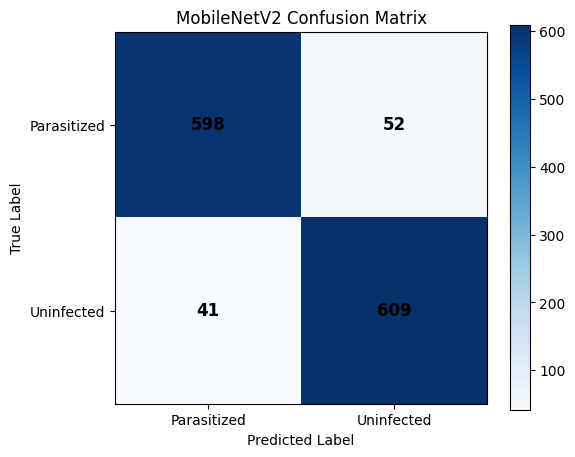

Confusion Matrix Saved Successfully!


In [31]:
# =====================================================
# STEP 5.14 – CONFUSION MATRIX
# =====================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import os

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(6,5))

plt.imshow(cm, interpolation="nearest", cmap="Blues")

plt.title("MobileNetV2 Confusion Matrix")

plt.colorbar()

classes = train_dataset.classes

tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            str(cm[i,j]),
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold"
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

save_path = "/content/drive/MyDrive/Malaria_Project/figures/mobilenet_confusion_matrix.png"

plt.savefig(save_path,
            dpi=300,
            bbox_inches="tight")

plt.show()

print("Confusion Matrix Saved Successfully!")

STEP 5.15 – ROC CURVE AND AUC SCORE

The Receiver Operating Characteristic (ROC) curve evaluates the classification model across different decision thresholds by plotting the True Positive Rate (Sensitivity) against the False Positive Rate (1 − Specificity). The Area Under the Curve (AUC) summarizes the ROC curve into a single value. An AUC closer to 1.0 indicates excellent classification performance. ROC-AUC is particularly important in medical image classification because it measures the model's ability to distinguish between diseased and healthy cases.

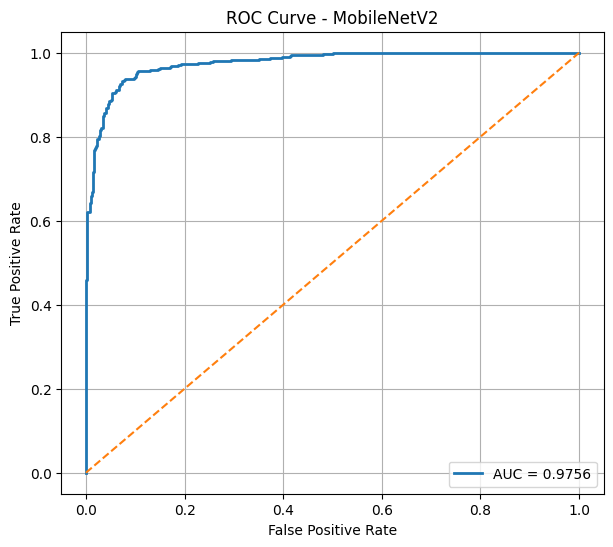

AUC Score : 0.9756


In [32]:
# =====================================================
# STEP 5.15 – ROC CURVE & AUC SCORE
# =====================================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import torch
import numpy as np

mobile_model.eval()

all_labels = []
all_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = mobile_model(images)

        # Convert logits to probabilities
        probabilities = torch.softmax(outputs, dim=1)

        # Probability of Positive Class (Uninfected)
        positive_prob = probabilities[:,1]

        all_labels.extend(labels.numpy())
        all_probabilities.extend(positive_prob.cpu().numpy())

# Calculate ROC

fpr, tpr, thresholds = roc_curve(
    all_labels,
    all_probabilities
)

roc_auc = auc(fpr, tpr)

# Plot

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - MobileNetV2")

plt.legend(loc="lower right")

plt.grid(True)

save_path="/content/drive/MyDrive/Malaria_Project/figures/mobilenet_roc_curve.png"

plt.savefig(save_path,dpi=300,bbox_inches="tight")

plt.show()

print("="*60)
print(f"AUC Score : {roc_auc:.4f}")
print("="*60)